In [7]:
import numpy as np
import matplotlib.pyplot as plt
import importlib
import ecc_vr 
importlib.reload(ecc_vr)
importlib.reload(ecc_vr.metrics)
import ecc_vr as vr

from pathlib import Path
import sys

week5_path = Path.cwd().parent / "Week5"
if str(week5_path) not in sys.path:
    sys.path.append(str(week5_path))

from Sphere_Ellipsoid_Utils import (
    unif_hypersphere,
    unif_hyperellipsoid,
    unit_ball_volume,
    scale_axes_target_volume,
    edge_count_curve,
    simulate_edge_curves,
    edge_count_curve_kde,
    simulate_edge_curves_kde,
    plot_sphere_ellipsoid_results
)


from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
)


In [8]:
# non uniform ellipsoid

def non_unif_hyperellipsoid(n_points, *stretch, r=1.0, center=None, seed=None):
    """
    Sample points on a hyperellipsoid boundary by sampling uniformly on the
    sphere and then stretching coordinate-wise.
    """
    rng = np.random.default_rng(seed)

    if len(stretch) == 1 and np.ndim(stretch[0]) != 0:
        a = np.asarray(stretch[0], dtype=float)
    else:
        a = np.asarray(stretch, dtype=float)

    if a.ndim != 1 or a.size == 0:
        raise ValueError("Provide one positive stretch value per dimension.")
    if np.any(a <= 0):
        raise ValueError("All stretch values must be > 0.")
    if r <= 0:
        raise ValueError("r must be > 0.")

    d = a.size

    if center is None:
        c = np.zeros(d, dtype=float)
    else:
        c = np.asarray(center, dtype=float)
        if c.shape != (d,):
            raise ValueError(f"center must have shape ({d},)")

    g = rng.normal(size=(n_points, d))
    u = g / np.linalg.norm(g, axis=1, keepdims=True)
    X = c + (r * u) * a
    return X


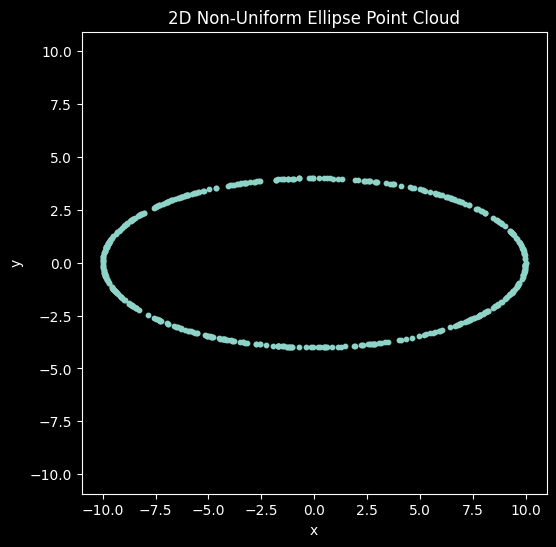

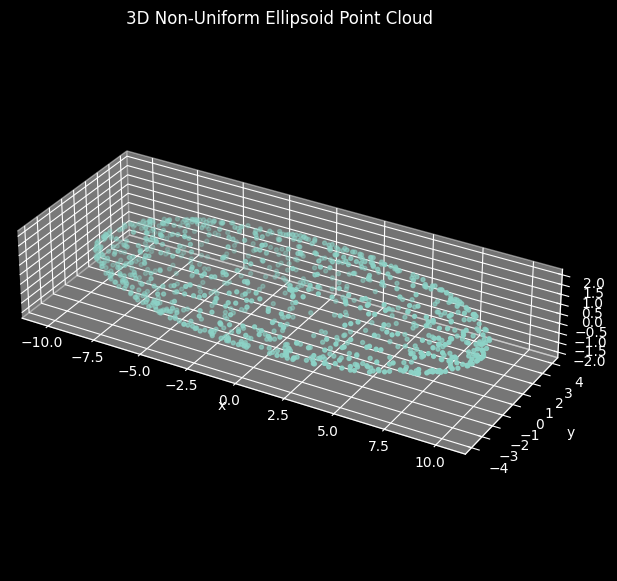

In [9]:
X2 = non_unif_hyperellipsoid(500, 10, 4, seed=0)

plt.figure(figsize=(6, 6))
plt.scatter(X2[:, 0], X2[:, 1], s=10)
plt.axis("equal")
plt.title("2D Non-Uniform Ellipse Point Cloud")
plt.xlabel("x")
plt.ylabel("y")
plt.show()


# 3D example
X3 = non_unif_hyperellipsoid(1000, 10, 4, 2, seed=0)

fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X3[:, 0], X3[:, 1], X3[:, 2], s=8)
ax.set_title("3D Non-Uniform Ellipsoid Point Cloud")
ax.set_aspect("equal")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
plt.show()

In [10]:
def sphere_vs_ellipsoid_edge_curve_classifier_kde(
        n_points: int = 100,
        t_grid: np.ndarray | None = None,
        n_resamples: int = 300,
        ambient_dim: int | None = None,
        ellipsoid_stretch: np.ndarray | list | tuple | None = None,
        h: float = 0.15,
        target_volume: float = 1.0,
        seed1: int = 42,
        seed2: int = 43,
        test_size: float = 0.25,
        random_state: int = 0,
):  
    
    if t_grid is None:
        t_grid = np.linspace(0.5, 5, 30)
    else:
        t_grid = np.asarray(t_grid, dtype = float)

    if ellipsoid_stretch is None:
        ambient_dim = 3 if ambient_dim is None else ambient_dim
        ellipsoid_stretch = np.ones(ambient_dim, dtype = float)
        ellipsoid_stretch[0] = 1.5
    else:
        ellipsoid_stretch = np.asarray(ellipsoid_stretch, dtype = float)
        if ambient_dim is None:
            ambient_dim = ellipsoid_stretch.size
            raise ValueError("ambient_dim must match len(ellipsoid_stretch).")
    
    target_volume = unit_ball_volume(ambient_dim) * np.prod(ellipsoid_stretch)
    
    sphere_radius = (target_volume / unit_ball_volume(ambient_dim)) ** ( 1.0 / ambient_dim)
    ellipsoid_axes = scale_axes_target_volume(ellipsoid_stretch, target_volume)

    curves_sphere = simulate_edge_curves_kde(
        point_cloud_sampler = lambda s: unif_hypersphere(
            n_points = n_points,
            d = ambient_dim,
            r = sphere_radius,
            seed = s,
        ),
        n_resamples=n_resamples,
        t_grid=t_grid,
        h = h,
        seed = seed1,
    )
    
    curves_ellipsoid = simulate_edge_curves_kde(
        point_cloud_sampler=lambda s: unif_hyperellipsoid(
            n_points,
            *ellipsoid_axes,
            seed = s,
        ),
        n_resamples=n_resamples,
        t_grid=t_grid,
        h = h,
        seed=seed2,
    )

    X = np.vstack([curves_sphere, curves_ellipsoid])
    y = np.array([0] * len(curves_sphere) + [1] * len(curves_ellipsoid))

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size = test_size,
        random_state=random_state,
        stratify=y
    )

    clf = make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter = 5000),
    )

    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    return {
        "shape1": "sphere",
        "shape2": "ellipsoid",
        "ambient_dim": ambient_dim,
        "target_volume": target_volume,
        "sphere_radius": sphere_radius,
        "ellipsoid_stretch_input": np.asarray(ellipsoid_stretch, dtype = float),
        "ellipsoid_axes": ellipsoid_axes,
        "t_grid": t_grid,
        "curves1": curves_sphere,
        "curves2": curves_ellipsoid,
        "curves_sphere": curves_sphere,
        "curves_ellipsoid": curves_ellipsoid,
        "classifier": clf,
        "accuracy": accuracy_score(y_test, y_pred),
        "report": classification_report(
            y_test,
            y_pred,
            target_names=["Sphere", "Ellipsoid"],
            zero_division=0,
        ),
        "X_test": X_test,
        "y_test": y_test,
        "y_pred": y_pred,
    }

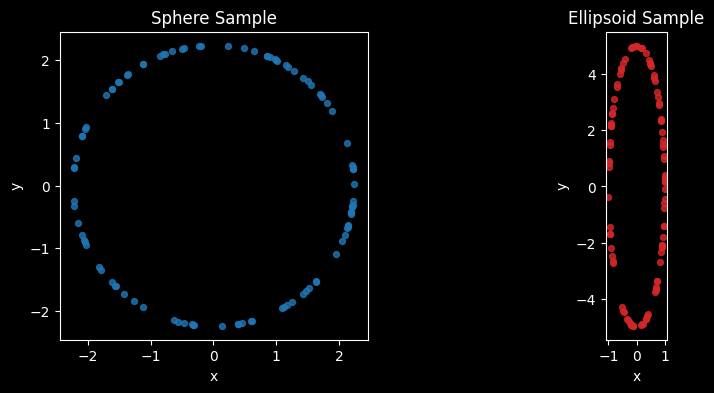

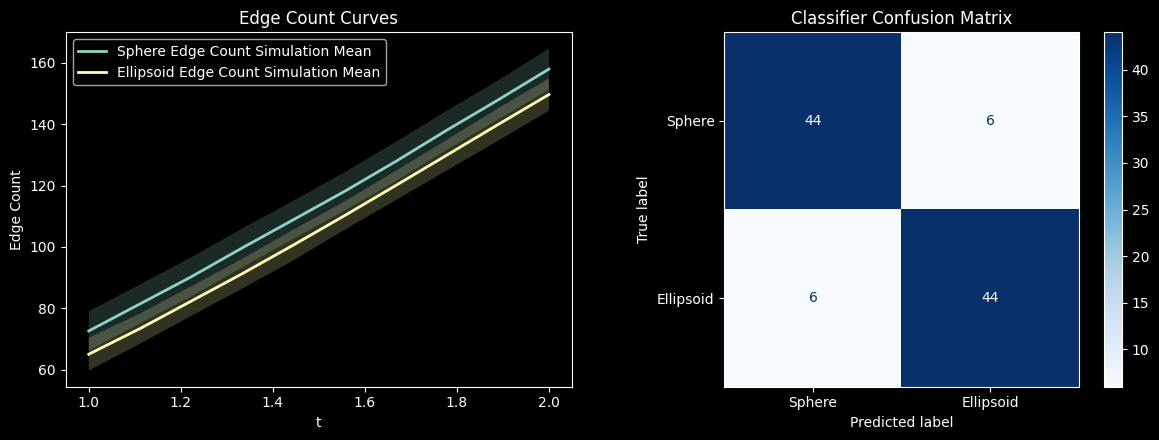

Accuracy: 0.88
              precision    recall  f1-score   support

      Sphere       0.88      0.88      0.88        50
   Ellipsoid       0.88      0.88      0.88        50

    accuracy                           0.88       100
   macro avg       0.88      0.88      0.88       100
weighted avg       0.88      0.88      0.88       100



In [11]:
plt.style.use("dark_background")

# INPUT
n_points = 100
n_resamples = 200
ambient_dim = 2
t_grid = np.linspace(1,2,10)
h = 0.2
ellipsoid_stretch = [1.0, 5.0]

result = sphere_vs_ellipsoid_edge_curve_classifier_kde(
    ambient_dim=ambient_dim,
    n_points=n_points,
    n_resamples=n_resamples,
    t_grid=t_grid,
    h = h,
    ellipsoid_stretch=ellipsoid_stretch,
)

fig = plt.figure(figsize=(10, 4))

samples = [
    ("Sphere", unif_hypersphere(n_points, result["ambient_dim"], r = result["sphere_radius"], seed = 123), "tab:blue"),
    ("Ellipsoid", non_unif_hyperellipsoid(n_points, result["ellipsoid_axes"], seed = 456), "tab:red"),
]

for i, (shape, X, color) in enumerate(samples, start = 1):
    projected = X.shape[1] > 3
    if projected:
        X = vr.pca_project(X, out_dim = 2)
    
    d = X.shape[1]
    ax = fig.add_subplot(1, 2, i, projection="3d" if d == 3 else None)

    if d == 3:
        ax.scatter(X[:, 0], X[:, 1], X[:, 2], s = 18, alpha = 0.8, color=color)
        ax.set_aspect("equal")
        ax.set_xlabel("x")
        ax.set_ylabel("y")
        ax.set_zlabel("z")
    elif d == 2:
        ax.scatter(X[:, 0], X[:, 1], s=18, alpha=0.8, color=color)
        ax.set_aspect("equal")
        ax.set_xlabel("PC1" if projected else "x")
        ax.set_ylabel("PC2" if projected else "y")
    else:
        ax.scatter(X[:, 0], np.zeros(len(X)), s=18, alpha=0.8, color=color)
        ax.set_xlabel("x")
        ax.set_ylabel("")

    ax.set_title(f"{shape} Sample")
    ax.grid(False)

plot_sphere_ellipsoid_results(result)

In [14]:
def compare_stretch_patterns(
    patterns,
    stretch_values,
    ambient_dim=3,
    n_points=100,
    n_resamples=100,
    t_grid=None,
    n_repeats=5,
):
    if t_grid is None:
        t_grid = np.linspace(0.5, 3.0, 15)
    else:
        t_grid = np.asarray(t_grid, dtype=float)

    stretch_values = np.asarray(stretch_values, dtype=float)
    summary = {}

    for name, pattern_fn in patterns.items():
        mean_acc = []
        sd_acc = []
        all_acc = []

        for s in stretch_values:
            run_acc = []

            for r in range(n_repeats):
                ellipsoid_stretch = np.asarray(pattern_fn(s, ambient_dim), dtype=float)

                if ellipsoid_stretch.shape != (ambient_dim,):
                    raise ValueError(
                        f"Pattern {name!r} returned shape {ellipsoid_stretch.shape}, expected {(ambient_dim,)}"
                    )

                result = sphere_vs_ellipsoid_edge_curve_classifier_kde(
                    ambient_dim=ambient_dim,
                    n_points=n_points,
                    n_resamples=n_resamples,
                    t_grid=t_grid,
                    ellipsoid_stretch=ellipsoid_stretch,
                    seed1=1000 + r,
                    seed2=2000 + r,
                    random_state=r,
                )

                run_acc.append(result["accuracy"])

            run_acc = np.asarray(run_acc, dtype=float)
            all_acc.append(run_acc)
            mean_acc.append(run_acc.mean())
            sd_acc.append(run_acc.std(ddof=1) if len(run_acc) > 1 else 0.0)

        summary[name] = {
            "mean_acc": np.asarray(mean_acc, dtype=float),
            "sd_acc": np.asarray(sd_acc, dtype=float),
            "all_acc": all_acc,
        }

    return {
        "patterns": patterns,
        "stretch_values": stretch_values,
        "summary": summary,
        "ambient_dim": ambient_dim,
        "n_points": n_points,
        "n_resamples": n_resamples,
        "n_repeats": n_repeats,
        "t_grid": t_grid,
    }

def plot_stretch_pattern_comparison(results, accuracy_target=None):
    stretch_values = results["stretch_values"]
    summary = results["summary"]
    ambient_dim = results["ambient_dim"]

    plt.style.use("default")
    plt.figure(figsize=(8, 5))

    for name, vals in summary.items():
        mean_acc = vals["mean_acc"]
        sd_acc = vals["sd_acc"]

        plt.plot(stretch_values, mean_acc, marker="o", lw=2, label=name)
        plt.fill_between(
            stretch_values,
            mean_acc - sd_acc,
            mean_acc + sd_acc,
            alpha=0.15,
        )

    if accuracy_target is not None:
        plt.axhline(
            accuracy_target,
            ls="--",
            color="tab:red",
            label=f"{accuracy_target:.0%} target",
        )

    plt.xlabel("Stretch parameter s")
    plt.ylabel("Classification accuracy")
    plt.title(f"Sphere vs Ellipsoid: Stretch Pattern Comparison in {ambient_dim}D")
    plt.ylim(0, 1.05)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    for name, vals in summary.items():
        mean_acc = vals["mean_acc"]
        sd_acc = vals["sd_acc"]

        print(name)
        for s, acc, sd in zip(stretch_values, mean_acc, sd_acc):
            print(f"  s={s:.3f}   mean_acc={acc:.3f}   sd={sd:.3f}")

        if accuracy_target is not None:
            good = np.where(mean_acc >= accuracy_target)[0]
            if len(good) > 0:
                print(f"  first stretch reaching {accuracy_target:.0%}: {stretch_values[good[0]]:.3f}")
            else:
                print(f"  no tested stretch reached {accuracy_target:.0%}")

        print()
        

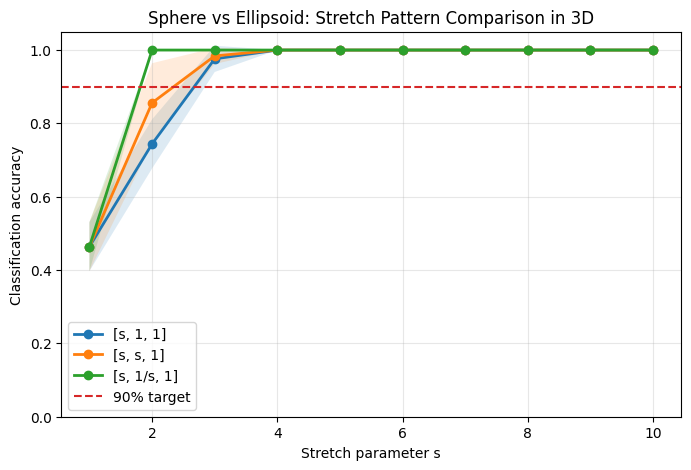

[s, 1, 1]
  s=1.000   mean_acc=0.464   sd=0.067
  s=2.000   mean_acc=0.744   sd=0.067
  s=3.000   mean_acc=0.976   sd=0.036
  s=4.000   mean_acc=1.000   sd=0.000
  s=5.000   mean_acc=1.000   sd=0.000
  s=6.000   mean_acc=1.000   sd=0.000
  s=7.000   mean_acc=1.000   sd=0.000
  s=8.000   mean_acc=1.000   sd=0.000
  s=9.000   mean_acc=1.000   sd=0.000
  s=10.000   mean_acc=1.000   sd=0.000
  first stretch reaching 90%: 3.000

[s, s, 1]
  s=1.000   mean_acc=0.464   sd=0.067
  s=2.000   mean_acc=0.856   sd=0.108
  s=3.000   mean_acc=0.984   sd=0.022
  s=4.000   mean_acc=1.000   sd=0.000
  s=5.000   mean_acc=1.000   sd=0.000
  s=6.000   mean_acc=1.000   sd=0.000
  s=7.000   mean_acc=1.000   sd=0.000
  s=8.000   mean_acc=1.000   sd=0.000
  s=9.000   mean_acc=1.000   sd=0.000
  s=10.000   mean_acc=1.000   sd=0.000
  first stretch reaching 90%: 3.000

[s, 1/s, 1]
  s=1.000   mean_acc=0.464   sd=0.067
  s=2.000   mean_acc=1.000   sd=0.000
  s=3.000   mean_acc=1.000   sd=0.000
  s=4.000   mean_a

In [15]:
ambient_dim = 3
stretch_values = np.linspace(1.0, 10.0, 10)

if ambient_dim == 2:
    patterns = {
        "[s, 1]": lambda s, d: [s] + [1.0] * (d - 1),
        "[s, s]": lambda s, d: [s, s] + [1.0] * (d - 2),
        "[s, 1/s]": lambda s, d: [s, 1.0 / s] + [1.0] * (d - 2),
    }
elif ambient_dim == 3:
    patterns = {
        "[s, 1, 1]": lambda s, d: [s] + [1.0] * (d - 1),
        "[s, s, 1]": lambda s, d: [s, s] + [1.0] * (d - 2),
        "[s, 1/s, 1]": lambda s, d: [s, 1.0 / s] + [1.0] * (d - 2),
    }
else:
    patterns = {
        "[s, 1, 1, ..., 1]": lambda s, d: [s] + [1.0] * (d - 1),
        "[s, s, 1, ..., 1]": lambda s, d: [s, s] + [1.0] * (d - 2),
        "[s, 1/s, 1, ..., 1]": lambda s, d: [s, 1.0 / s] + [1.0] * (d - 2),
    }

results = compare_stretch_patterns(
    patterns=patterns,
    stretch_values=stretch_values,
    ambient_dim=ambient_dim,
    n_points=200,
    n_resamples=50,
    t_grid=np.linspace(1.0, 2.0, 5),
    n_repeats=5,
)

plot_stretch_pattern_comparison(results, accuracy_target=0.90)
